## Import libraries

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import optuna

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.model_selection import (
    StratifiedKFold, LeaveOneGroupOut,
    cross_validate, cross_val_predict, cross_val_score,
)
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif, RFE
from sklearn.ensemble import RandomForestClassifier

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap
import pacmap

from sklearn.metrics import f1_score, roc_auc_score
import shap
shap.initjs()

## Load data

In [41]:
# Load clinical_gex
clinical_gex = pd.read_csv(f"../dataset/created/tcga_gdc.csv", low_memory=False)

print(clinical_gex.shape)
clinical_gex.head()

(292, 40815)


,SAMPLE_ID,A1BG,NAT2,ADA,CDH2,AKT3,GAGE12F,LINC02584,POU5F1P5,POU5F1P6,...,PATH_N_STAGE,PATH_STAGE,PATH_T_STAGE,PRIMARY_SITE_PATIENT,PRIOR_MALIGNANCY,PRIOR_TREATMENT,RACE,SEX,YEAR_OF_DIAGNOSIS,os_label
0,TCGA-3N-A9WB-06A,0.2460,0.0000,12.4774,0.0358,35.3259,0.0,0.0000,0.0,0.0621,...,NX,Stage IA,T1a,Trunk,False,False,WHITE,Male,2012.0,0
1,TCGA-3N-A9WD-06A,0.3119,0.0000,10.5382,0.4456,13.0935,0.0,0.6626,0.0,0.0840,...,N1a,Stage IIIA,T2a,Other Specify,False,False,WHITE,Male,2013.0,0
2,TCGA-BF-A1PX-01A,0.1272,0.0305,14.9661,1.1447,10.2892,0.0,0.0780,0.0,0.2768,...,N2a,Stage IIIB,T4b,Trunk,False,False,WHITE,Male,2010.0,0
3,TCGA-D3-A1Q1-06A,0.8970,0.0000,51.9998,0.1713,72.1101,0.0,0.0000,0.0,0.1782,...,N3,Stage IIIC,T1b,Extremities,False,False,WHITE,Female,2004.0,0
4,TCGA-D3-A1Q3-06A,0.2530,0.0000,12.0290,23.6309,65.5314,0.0,0.0000,0.0,0.2222,...,N0,Stage IIC,T4b,Extremities,False,True,WHITE,Male,2001.0,0


In [42]:
# Clinical feature groups
clinical_categorical_cols = ['ETHNICITY', 'ICD_10', 'MORPHOLOGY', 'SAMPLE_TYPE',
                            'PATH_M_STAGE', 'PATH_N_STAGE', 'PATH_STAGE', 'PATH_T_STAGE',
                            'PRIMARY_SITE_PATIENT', 'PRIOR_MALIGNANCY', 'PRIOR_TREATMENT', 'RACE',
                            'SEX']
clinical_numeric_col    = ['AGE', 'TMB_NONSYNONYMOUS']
clinical_remaining_cols = ['PATIENT_ID', 'SAMPLE_ID', 'YEAR_OF_DIAGNOSIS', 'os_label']

In [43]:
CLINICAL_COLS = (clinical_categorical_cols + clinical_numeric_col + clinical_remaining_cols)

GEX_COLS_ORI = [c for c in clinical_gex.columns if c not in CLINICAL_COLS]

print('Original clinical_gex features:')
print(f'clinical + gex = {len(CLINICAL_COLS)} + {len(GEX_COLS_ORI)} = {len(CLINICAL_COLS)+len(GEX_COLS_ORI)}')

Original clinical_gex features:
clinical + gex = 19 + 40796 = 40815


In [44]:
from sklearn.model_selection import train_test_split

# Split x, y
clinical_gex.columns = clinical_gex.columns.str.strip()

y = clinical_gex['os_label']
x = clinical_gex.drop(clinical_remaining_cols, axis=1)

print(f'Dropped {len(clinical_remaining_cols)} clinical cols, {x.shape} remaining')
x.head()

Dropped 4 clinical cols, (292, 40811) remaining


,A1BG,NAT2,ADA,CDH2,AKT3,GAGE12F,LINC02584,POU5F1P5,POU5F1P6,POU5F1P7,...,MORPHOLOGY,PATH_M_STAGE,PATH_N_STAGE,PATH_STAGE,PATH_T_STAGE,PRIMARY_SITE_PATIENT,PRIOR_MALIGNANCY,PRIOR_TREATMENT,RACE,SEX
0,0.2460,0.0000,12.4774,0.0358,35.3259,0.0,0.0000,0.0,0.0621,0.0,...,8720/3,M0,NX,Stage IA,T1a,Trunk,False,False,WHITE,Male
1,0.3119,0.0000,10.5382,0.4456,13.0935,0.0,0.6626,0.0,0.0840,0.0,...,8720/3,M0,N1a,Stage IIIA,T2a,Other Specify,False,False,WHITE,Male
2,0.1272,0.0305,14.9661,1.1447,10.2892,0.0,0.0780,0.0,0.2768,0.0,...,8720/3,M0,N2a,Stage IIIB,T4b,Trunk,False,False,WHITE,Male
3,0.8970,0.0000,51.9998,0.1713,72.1101,0.0,0.0000,0.0,0.1782,0.0,...,8720/3,M0,N3,Stage IIIC,T1b,Extremities,False,False,WHITE,Female
4,0.2530,0.0000,12.0290,23.6309,65.5314,0.0,0.0000,0.0,0.2222,0.0,...,8720/3,M0,N0,Stage IIC,T4b,Extremities,False,True,WHITE,Male


In [45]:
print(f"\nTarget distribution:\n{y.value_counts().sort_index()}")


Target distribution:
os_label
0    172
1    120
Name: count, dtype: int64


## Preprocessing Pipeline

In [46]:
ordinal_categorical_cols = ['PATH_T_STAGE', 'PATH_N_STAGE', 'PATH_M_STAGE', 'PATH_STAGE']
nominal_categorical_cols = [c for c in clinical_categorical_cols if c not in ordinal_categorical_cols]

# X/NOS = not assessed / not otherwise specified, placed last
T_STAGE_ORDER = ['Tis', 'T0', 'T1', 'T1a', 'T1b', 'T2', 'T2a', 'T2b', 'T3', 'T3a', 'T3b', 'T4', 'T4a', 'T4b', 'TX']
N_STAGE_ORDER = ['N0', 'N1', 'N1a', 'N1b', 'N2', 'N2a', 'N2b', 'N2c', 'N3', 'NX']
M_STAGE_ORDER = ['M0', 'M1a', 'M1b', 'M1c', 'M1']
PATH_STAGE_ORDER = ['Stage 0', 'Stage I', 'Stage IA', 'Stage IB', 'Stage II', 'Stage IIA', 'Stage IIB',
                    'Stage IIC', 'Stage III', 'Stage IIIA', 'Stage IIIB', 'Stage IIIC', 'Stage IV', 'I/II NOS']

preprocess_features = ColumnTransformer(
    transformers=[
        # ('categorical', Pipeline([
        #     ('imputer', SimpleImputer(strategy='most_frequent')),
        #     ('ohe', OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='if_binary')),
        # ]), nominal_categorical_cols),

        # ('ordinal', Pipeline([
        #     ('imputer', SimpleImputer(strategy='most_frequent')),
        #     ('ord', OrdinalEncoder(categories=[T_STAGE_ORDER, N_STAGE_ORDER, M_STAGE_ORDER, PATH_STAGE_ORDER],
        #                             handle_unknown='use_encoded_value', unknown_value=-1)),
        # ]), ordinal_categorical_cols),

        # ('numeric',      SimpleImputer(strategy='median'), clinical_numeric_col),

        ('gex', Pipeline([
            ('variance', VarianceThreshold(threshold=0.1)),
            ('kbest',    SelectKBest(f_classif, k=20)),
        ]), GEX_COLS_ORI),
    ],
    remainder='drop',
)

In [47]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lr_clf = LogisticRegression(
    solver='saga',
    class_weight='balanced',
    max_iter=5000,
    random_state=42,
    # C=1.0,
    # l1_ratio=0
)

full_pipe = Pipeline([
    ('preprocess', preprocess_features),
    ('scaler', StandardScaler()),
    ('clf', lr_clf)
])

full_pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('gex', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spa

In [48]:
def objective(trial):
    params = {
            'clf__C':        trial.suggest_float('clf__C', 1e-3, 1.0, log=True),
            'clf__l1_ratio': trial.suggest_categorical('clf__l1_ratio', [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]),
            'preprocess__gex__kbest__k': trial.suggest_int('preprocess__gex__kbest__k', 5, 20)
        }
    
    full_pipe.set_params(**params)
    scores = cross_val_score(full_pipe, x, y, cv=skf, scoring='f1', n_jobs=-1)
        
    return scores.mean()

study = optuna.create_study(direction='maximize',
                            sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=100, show_progress_bar=True)

print(study.best_params)
print(f"Best CV F1 (or macro F1 if 3 classes): {study.best_value:.3f}")
full_pipe.set_params(**study.best_params)

[I 2026-07-21 14:14:32,083] A new study created in memory with name: no-name-072664e8-96fa-48ae-8ab2-18a3e3663ace
Best trial: 0. Best value: 0.232736:   1%|          | 1/100 [00:02<04:45,  2.88s/it]

[I 2026-07-21 14:14:34,965] Trial 0 finished with value: 0.23273582133411694 and parameters: {'clf__C': 0.013292918943162165, 'clf__l1_ratio': 1.0, 'preprocess__gex__kbest__k': 18}. Best is trial 0 with value: 0.23273582133411694.


Best trial: 1. Best value: 0.582545:   2%|▏         | 2/100 [00:04<03:51,  2.36s/it]

[I 2026-07-21 14:14:36,964] Trial 1 finished with value: 0.5825448133999412 and parameters: {'clf__C': 0.004335281794951566, 'clf__l1_ratio': 0.6, 'preprocess__gex__kbest__k': 17}. Best is trial 1 with value: 0.5825448133999412.


Best trial: 1. Best value: 0.582545:   3%|▎         | 3/100 [00:07<03:38,  2.25s/it]

[I 2026-07-21 14:14:39,085] Trial 2 finished with value: 0.5825448133999412 and parameters: {'clf__C': 0.003972110727381913, 'clf__l1_ratio': 0.7, 'preprocess__gex__kbest__k': 15}. Best is trial 1 with value: 0.5825448133999412.


Best trial: 1. Best value: 0.582545:   4%|▍         | 4/100 [00:09<03:27,  2.16s/it]

[I 2026-07-21 14:14:41,109] Trial 3 finished with value: 0.11566265060240963 and parameters: {'clf__C': 0.020914981329035603, 'clf__l1_ratio': 1.0, 'preprocess__gex__kbest__k': 17}. Best is trial 1 with value: 0.5825448133999412.


Best trial: 1. Best value: 0.582545:   5%|▌         | 5/100 [00:10<02:45,  1.74s/it]

[I 2026-07-21 14:14:42,096] Trial 4 finished with value: 0.5476389828658736 and parameters: {'clf__C': 0.6584106160121611, 'clf__l1_ratio': 0.2, 'preprocess__gex__kbest__k': 9}. Best is trial 1 with value: 0.5825448133999412.


Best trial: 1. Best value: 0.582545:   6%|▌         | 6/100 [00:11<02:22,  1.52s/it]

[I 2026-07-21 14:14:43,181] Trial 5 finished with value: 0.5158950679389556 and parameters: {'clf__C': 0.042470585622618684, 'clf__l1_ratio': 0.3, 'preprocess__gex__kbest__k': 6}. Best is trial 1 with value: 0.5825448133999412.


Best trial: 1. Best value: 0.582545:   7%|▋         | 7/100 [00:12<02:04,  1.34s/it]

[I 2026-07-21 14:14:44,156] Trial 6 finished with value: 0.11566265060240963 and parameters: {'clf__C': 0.011895896737553546, 'clf__l1_ratio': 0.9, 'preprocess__gex__kbest__k': 6}. Best is trial 1 with value: 0.5825448133999412.


Best trial: 1. Best value: 0.582545:   8%|▊         | 8/100 [00:13<01:51,  1.21s/it]

[I 2026-07-21 14:14:45,105] Trial 7 finished with value: 0.5445762207815381 and parameters: {'clf__C': 0.13795402040204174, 'clf__l1_ratio': 0.2, 'preprocess__gex__kbest__k': 13}. Best is trial 1 with value: 0.5825448133999412.


Best trial: 1. Best value: 0.582545:   9%|▉         | 9/100 [00:14<01:44,  1.15s/it]

[I 2026-07-21 14:14:46,101] Trial 8 finished with value: 0.5547667918231123 and parameters: {'clf__C': 0.5280796376895364, 'clf__l1_ratio': 0.7, 'preprocess__gex__kbest__k': 17}. Best is trial 1 with value: 0.5825448133999412.


Best trial: 1. Best value: 0.582545:  10%|█         | 10/100 [00:14<01:38,  1.09s/it]

[I 2026-07-21 14:14:47,070] Trial 9 finished with value: 0.3498089920658242 and parameters: {'clf__C': 0.003628358380354917, 'clf__l1_ratio': 0.3, 'preprocess__gex__kbest__k': 13}. Best is trial 1 with value: 0.5825448133999412.


Best trial: 1. Best value: 0.582545:  11%|█         | 11/100 [00:16<01:36,  1.08s/it]

[I 2026-07-21 14:14:48,119] Trial 10 finished with value: 0.5825448133999412 and parameters: {'clf__C': 0.0011890625822974646, 'clf__l1_ratio': 0.6, 'preprocess__gex__kbest__k': 20}. Best is trial 1 with value: 0.5825448133999412.


Best trial: 1. Best value: 0.582545:  12%|█▏        | 12/100 [00:16<01:30,  1.03s/it]

[I 2026-07-21 14:14:49,037] Trial 11 finished with value: 0.5825448133999412 and parameters: {'clf__C': 0.002744640930074699, 'clf__l1_ratio': 0.8, 'preprocess__gex__kbest__k': 15}. Best is trial 1 with value: 0.5825448133999412.


Best trial: 1. Best value: 0.582545:  13%|█▎        | 13/100 [00:17<01:26,  1.01it/s]

[I 2026-07-21 14:14:49,938] Trial 12 finished with value: 0.5825448133999412 and parameters: {'clf__C': 0.0038437748333144096, 'clf__l1_ratio': 0.4, 'preprocess__gex__kbest__k': 10}. Best is trial 1 with value: 0.5825448133999412.


Best trial: 1. Best value: 0.582545:  14%|█▍        | 14/100 [00:18<01:23,  1.03it/s]

[I 2026-07-21 14:14:50,858] Trial 13 finished with value: 0.5825448133999412 and parameters: {'clf__C': 0.001053986787619041, 'clf__l1_ratio': 0.7, 'preprocess__gex__kbest__k': 15}. Best is trial 1 with value: 0.5825448133999412.


Best trial: 1. Best value: 0.582545:  15%|█▌        | 15/100 [00:19<01:19,  1.06it/s]

[I 2026-07-21 14:14:51,729] Trial 14 finished with value: 0.3498089920658242 and parameters: {'clf__C': 0.007203821205189777, 'clf__l1_ratio': 0.6, 'preprocess__gex__kbest__k': 20}. Best is trial 1 with value: 0.5825448133999412.


Best trial: 1. Best value: 0.582545:  16%|█▌        | 16/100 [00:20<01:17,  1.08it/s]

[I 2026-07-21 14:14:52,619] Trial 15 finished with value: 0.515550389288908 and parameters: {'clf__C': 0.048128431462991304, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 15}. Best is trial 1 with value: 0.5825448133999412.


Best trial: 1. Best value: 0.582545:  17%|█▋        | 17/100 [00:21<01:16,  1.08it/s]

[I 2026-07-21 14:14:53,533] Trial 16 finished with value: 0.5433707596751074 and parameters: {'clf__C': 0.006323728543271075, 'clf__l1_ratio': 0.1, 'preprocess__gex__kbest__k': 11}. Best is trial 1 with value: 0.5825448133999412.


Best trial: 1. Best value: 0.582545:  18%|█▊        | 18/100 [00:22<01:14,  1.10it/s]

[I 2026-07-21 14:14:54,412] Trial 17 finished with value: 0.5377760017760017 and parameters: {'clf__C': 0.11432005018619464, 'clf__l1_ratio': 0.5, 'preprocess__gex__kbest__k': 18}. Best is trial 1 with value: 0.5825448133999412.


Best trial: 1. Best value: 0.582545:  19%|█▉        | 19/100 [00:23<01:12,  1.11it/s]

[I 2026-07-21 14:14:55,288] Trial 18 finished with value: 0.5825448133999412 and parameters: {'clf__C': 0.002118980420434305, 'clf__l1_ratio': 0.6, 'preprocess__gex__kbest__k': 14}. Best is trial 1 with value: 0.5825448133999412.


Best trial: 1. Best value: 0.582545:  20%|██        | 20/100 [00:24<01:11,  1.11it/s]

[I 2026-07-21 14:14:56,190] Trial 19 finished with value: 0.11566265060240963 and parameters: {'clf__C': 0.010675736963796117, 'clf__l1_ratio': 0.7, 'preprocess__gex__kbest__k': 11}. Best is trial 1 with value: 0.5825448133999412.


Best trial: 1. Best value: 0.582545:  21%|██        | 21/100 [00:24<01:10,  1.12it/s]

[I 2026-07-21 14:14:57,067] Trial 20 finished with value: 0.5383223288339567 and parameters: {'clf__C': 0.028884742019952996, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 17}. Best is trial 1 with value: 0.5825448133999412.


Best trial: 1. Best value: 0.582545:  22%|██▏       | 22/100 [00:25<01:10,  1.11it/s]

[I 2026-07-21 14:14:57,984] Trial 21 finished with value: 0.5825448133999412 and parameters: {'clf__C': 0.0013322078204125124, 'clf__l1_ratio': 0.6, 'preprocess__gex__kbest__k': 20}. Best is trial 1 with value: 0.5825448133999412.


Best trial: 1. Best value: 0.582545:  23%|██▎       | 23/100 [00:26<01:08,  1.13it/s]

[I 2026-07-21 14:14:58,841] Trial 22 finished with value: 0.5825448133999412 and parameters: {'clf__C': 0.001871475097186621, 'clf__l1_ratio': 0.6, 'preprocess__gex__kbest__k': 19}. Best is trial 1 with value: 0.5825448133999412.


Best trial: 1. Best value: 0.582545:  24%|██▍       | 24/100 [00:27<01:07,  1.13it/s]

[I 2026-07-21 14:14:59,725] Trial 23 finished with value: 0.5825448133999412 and parameters: {'clf__C': 0.005295370026846702, 'clf__l1_ratio': 0.6, 'preprocess__gex__kbest__k': 16}. Best is trial 1 with value: 0.5825448133999412.


Best trial: 1. Best value: 0.582545:  25%|██▌       | 25/100 [00:28<01:06,  1.13it/s]

[I 2026-07-21 14:15:00,607] Trial 24 finished with value: 0.5825448133999412 and parameters: {'clf__C': 0.0016482415148790944, 'clf__l1_ratio': 0.8, 'preprocess__gex__kbest__k': 19}. Best is trial 1 with value: 0.5825448133999412.


Best trial: 1. Best value: 0.582545:  26%|██▌       | 26/100 [00:29<01:05,  1.12it/s]

[I 2026-07-21 14:15:01,509] Trial 25 finished with value: 0.5825448133999412 and parameters: {'clf__C': 0.0010837283702397164, 'clf__l1_ratio': 0.9, 'preprocess__gex__kbest__k': 19}. Best is trial 1 with value: 0.5825448133999412.


Best trial: 1. Best value: 0.582545:  27%|██▋       | 27/100 [00:30<01:05,  1.12it/s]

[I 2026-07-21 14:15:02,401] Trial 26 finished with value: 0.5825448133999412 and parameters: {'clf__C': 0.003018500413765515, 'clf__l1_ratio': 0.4, 'preprocess__gex__kbest__k': 16}. Best is trial 1 with value: 0.5825448133999412.


Best trial: 1. Best value: 0.582545:  28%|██▊       | 28/100 [00:31<01:03,  1.13it/s]

[I 2026-07-21 14:15:03,280] Trial 27 finished with value: 0.5447649633920209 and parameters: {'clf__C': 0.004741483468924597, 'clf__l1_ratio': 0.1, 'preprocess__gex__kbest__k': 18}. Best is trial 1 with value: 0.5825448133999412.


Best trial: 1. Best value: 0.582545:  29%|██▉       | 29/100 [00:32<01:03,  1.12it/s]

[I 2026-07-21 14:15:04,174] Trial 28 finished with value: 0.3498089920658242 and parameters: {'clf__C': 0.009112084128938679, 'clf__l1_ratio': 0.5, 'preprocess__gex__kbest__k': 20}. Best is trial 1 with value: 0.5825448133999412.


Best trial: 1. Best value: 0.582545:  30%|███       | 30/100 [00:32<01:02,  1.12it/s]

[I 2026-07-21 14:15:05,070] Trial 29 finished with value: 0.5012222222222222 and parameters: {'clf__C': 0.022034990793445754, 'clf__l1_ratio': 0.7, 'preprocess__gex__kbest__k': 16}. Best is trial 1 with value: 0.5825448133999412.


Best trial: 1. Best value: 0.582545:  31%|███       | 31/100 [00:33<01:01,  1.13it/s]

[I 2026-07-21 14:15:05,945] Trial 30 finished with value: 0.11566265060240963 and parameters: {'clf__C': 0.01623351543004788, 'clf__l1_ratio': 1.0, 'preprocess__gex__kbest__k': 14}. Best is trial 1 with value: 0.5825448133999412.


Best trial: 1. Best value: 0.582545:  32%|███▏      | 32/100 [00:34<01:00,  1.13it/s]

[I 2026-07-21 14:15:06,830] Trial 31 finished with value: 0.5825448133999412 and parameters: {'clf__C': 0.002542738485721567, 'clf__l1_ratio': 0.8, 'preprocess__gex__kbest__k': 15}. Best is trial 1 with value: 0.5825448133999412.


Best trial: 1. Best value: 0.582545:  33%|███▎      | 33/100 [00:35<01:00,  1.11it/s]

[I 2026-07-21 14:15:07,767] Trial 32 finished with value: 0.5825448133999412 and parameters: {'clf__C': 0.002570114860722472, 'clf__l1_ratio': 0.8, 'preprocess__gex__kbest__k': 17}. Best is trial 1 with value: 0.5825448133999412.


Best trial: 1. Best value: 0.582545:  34%|███▍      | 34/100 [00:36<00:59,  1.10it/s]

[I 2026-07-21 14:15:08,684] Trial 33 finished with value: 0.5825448133999412 and parameters: {'clf__C': 0.0017200896059823103, 'clf__l1_ratio': 0.8, 'preprocess__gex__kbest__k': 18}. Best is trial 1 with value: 0.5825448133999412.


Best trial: 1. Best value: 0.582545:  35%|███▌      | 35/100 [00:37<00:59,  1.10it/s]

[I 2026-07-21 14:15:09,613] Trial 34 finished with value: 0.5825448133999412 and parameters: {'clf__C': 0.004109376103652626, 'clf__l1_ratio': 0.6, 'preprocess__gex__kbest__k': 12}. Best is trial 1 with value: 0.5825448133999412.


Best trial: 1. Best value: 0.582545:  36%|███▌      | 36/100 [00:38<00:57,  1.11it/s]

[I 2026-07-21 14:15:10,496] Trial 35 finished with value: 0.5026557414710725 and parameters: {'clf__C': 0.00741891438131016, 'clf__l1_ratio': 0.2, 'preprocess__gex__kbest__k': 14}. Best is trial 1 with value: 0.5825448133999412.


Best trial: 1. Best value: 0.582545:  37%|███▋      | 37/100 [00:39<00:57,  1.10it/s]

[I 2026-07-21 14:15:11,404] Trial 36 finished with value: 0.5825448133999412 and parameters: {'clf__C': 0.0010178003043657493, 'clf__l1_ratio': 0.6, 'preprocess__gex__kbest__k': 8}. Best is trial 1 with value: 0.5825448133999412.


Best trial: 1. Best value: 0.582545:  38%|███▊      | 38/100 [00:40<00:55,  1.11it/s]

[I 2026-07-21 14:15:12,289] Trial 37 finished with value: 0.11566265060240963 and parameters: {'clf__C': 0.015918842946946583, 'clf__l1_ratio': 1.0, 'preprocess__gex__kbest__k': 16}. Best is trial 1 with value: 0.5825448133999412.


Best trial: 1. Best value: 0.582545:  39%|███▉      | 39/100 [00:41<00:54,  1.12it/s]

[I 2026-07-21 14:15:13,163] Trial 38 finished with value: 0.5464868964994122 and parameters: {'clf__C': 0.9415244195298776, 'clf__l1_ratio': 0.7, 'preprocess__gex__kbest__k': 13}. Best is trial 1 with value: 0.5825448133999412.


Best trial: 1. Best value: 0.582545:  40%|████      | 40/100 [00:41<00:53,  1.11it/s]

[I 2026-07-21 14:15:14,074] Trial 39 finished with value: 0.5825448133999412 and parameters: {'clf__C': 0.002957013999218734, 'clf__l1_ratio': 0.9, 'preprocess__gex__kbest__k': 5}. Best is trial 1 with value: 0.5825448133999412.


Best trial: 1. Best value: 0.582545:  41%|████      | 41/100 [00:42<00:52,  1.12it/s]

[I 2026-07-21 14:15:14,957] Trial 40 finished with value: 0.5358764111705288 and parameters: {'clf__C': 0.06324298109089424, 'clf__l1_ratio': 0.3, 'preprocess__gex__kbest__k': 17}. Best is trial 1 with value: 0.5825448133999412.


Best trial: 1. Best value: 0.582545:  42%|████▏     | 42/100 [00:43<00:51,  1.13it/s]

[I 2026-07-21 14:15:15,827] Trial 41 finished with value: 0.3498089920658242 and parameters: {'clf__C': 0.004275053935104816, 'clf__l1_ratio': 0.4, 'preprocess__gex__kbest__k': 9}. Best is trial 1 with value: 0.5825448133999412.


Best trial: 1. Best value: 0.582545:  43%|████▎     | 43/100 [00:44<00:50,  1.13it/s]

[I 2026-07-21 14:15:16,699] Trial 42 finished with value: 0.5825448133999412 and parameters: {'clf__C': 0.0015977158564829523, 'clf__l1_ratio': 0.4, 'preprocess__gex__kbest__k': 11}. Best is trial 1 with value: 0.5825448133999412.


Best trial: 1. Best value: 0.582545:  44%|████▍     | 44/100 [00:45<00:49,  1.13it/s]

[I 2026-07-21 14:15:17,580] Trial 43 finished with value: 0.5825448133999412 and parameters: {'clf__C': 0.0035285691700295448, 'clf__l1_ratio': 0.4, 'preprocess__gex__kbest__k': 9}. Best is trial 1 with value: 0.5825448133999412.


Best trial: 1. Best value: 0.582545:  45%|████▌     | 45/100 [00:46<00:48,  1.13it/s]

[I 2026-07-21 14:15:18,475] Trial 44 finished with value: 0.5248067891188096 and parameters: {'clf__C': 0.25805052313179416, 'clf__l1_ratio': 0.2, 'preprocess__gex__kbest__k': 15}. Best is trial 1 with value: 0.5825448133999412.


Best trial: 1. Best value: 0.582545:  46%|████▌     | 46/100 [00:47<00:47,  1.13it/s]

[I 2026-07-21 14:15:19,348] Trial 45 finished with value: 0.23273582133411694 and parameters: {'clf__C': 0.005887986766198399, 'clf__l1_ratio': 0.4, 'preprocess__gex__kbest__k': 10}. Best is trial 1 with value: 0.5825448133999412.


Best trial: 1. Best value: 0.582545:  47%|████▋     | 47/100 [00:48<00:46,  1.14it/s]

[I 2026-07-21 14:15:20,226] Trial 46 finished with value: 0.5825448133999412 and parameters: {'clf__C': 0.0023067397250649897, 'clf__l1_ratio': 0.7, 'preprocess__gex__kbest__k': 7}. Best is trial 1 with value: 0.5825448133999412.


Best trial: 1. Best value: 0.582545:  48%|████▊     | 48/100 [00:48<00:45,  1.14it/s]

[I 2026-07-21 14:15:21,083] Trial 47 finished with value: 0.5556976964271797 and parameters: {'clf__C': 0.00883817257021099, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 12}. Best is trial 1 with value: 0.5825448133999412.


Best trial: 1. Best value: 0.582545:  49%|████▉     | 49/100 [00:49<00:44,  1.15it/s]

[I 2026-07-21 14:15:21,952] Trial 48 finished with value: 0.5825448133999412 and parameters: {'clf__C': 0.0012822954499399838, 'clf__l1_ratio': 0.6, 'preprocess__gex__kbest__k': 14}. Best is trial 1 with value: 0.5825448133999412.


Best trial: 1. Best value: 0.582545:  50%|█████     | 50/100 [00:50<00:43,  1.15it/s]

[I 2026-07-21 14:15:22,817] Trial 49 finished with value: 0.5067157026612465 and parameters: {'clf__C': 0.013011177923071044, 'clf__l1_ratio': 0.3, 'preprocess__gex__kbest__k': 10}. Best is trial 1 with value: 0.5825448133999412.


Best trial: 1. Best value: 0.582545:  51%|█████     | 51/100 [00:51<00:42,  1.14it/s]

[I 2026-07-21 14:15:23,704] Trial 50 finished with value: 0.5152925170068027 and parameters: {'clf__C': 0.003341268153834107, 'clf__l1_ratio': 0.1, 'preprocess__gex__kbest__k': 13}. Best is trial 1 with value: 0.5825448133999412.


Best trial: 1. Best value: 0.582545:  52%|█████▏    | 52/100 [00:52<00:42,  1.13it/s]

[I 2026-07-21 14:15:24,617] Trial 51 finished with value: 0.5825448133999412 and parameters: {'clf__C': 0.0013064773943315473, 'clf__l1_ratio': 0.7, 'preprocess__gex__kbest__k': 15}. Best is trial 1 with value: 0.5825448133999412.


Best trial: 1. Best value: 0.582545:  53%|█████▎    | 53/100 [00:53<00:41,  1.13it/s]

[I 2026-07-21 14:15:25,501] Trial 52 finished with value: 0.5825448133999412 and parameters: {'clf__C': 0.002049510562626934, 'clf__l1_ratio': 0.7, 'preprocess__gex__kbest__k': 15}. Best is trial 1 with value: 0.5825448133999412.


Best trial: 1. Best value: 0.582545:  54%|█████▍    | 54/100 [00:54<00:40,  1.14it/s]

[I 2026-07-21 14:15:26,366] Trial 53 finished with value: 0.5825448133999412 and parameters: {'clf__C': 0.0016227297099712787, 'clf__l1_ratio': 0.7, 'preprocess__gex__kbest__k': 17}. Best is trial 1 with value: 0.5825448133999412.


Best trial: 1. Best value: 0.582545:  55%|█████▌    | 55/100 [00:55<00:39,  1.14it/s]

[I 2026-07-21 14:15:27,245] Trial 54 finished with value: 0.5825448133999412 and parameters: {'clf__C': 0.005984901188564894, 'clf__l1_ratio': 0.8, 'preprocess__gex__kbest__k': 18}. Best is trial 1 with value: 0.5825448133999412.


Best trial: 1. Best value: 0.582545:  56%|█████▌    | 56/100 [00:56<00:38,  1.14it/s]

[I 2026-07-21 14:15:28,122] Trial 55 finished with value: 0.5825448133999412 and parameters: {'clf__C': 0.0010922102734720995, 'clf__l1_ratio': 0.6, 'preprocess__gex__kbest__k': 16}. Best is trial 1 with value: 0.5825448133999412.


Best trial: 1. Best value: 0.582545:  57%|█████▋    | 57/100 [00:56<00:37,  1.14it/s]

[I 2026-07-21 14:15:28,989] Trial 56 finished with value: 0.5825448133999412 and parameters: {'clf__C': 0.00221957095598952, 'clf__l1_ratio': 0.5, 'preprocess__gex__kbest__k': 19}. Best is trial 1 with value: 0.5825448133999412.


Best trial: 1. Best value: 0.582545:  58%|█████▊    | 58/100 [00:57<00:35,  1.18it/s]

[I 2026-07-21 14:15:29,783] Trial 57 finished with value: 0.5825448133999412 and parameters: {'clf__C': 0.004807743149803908, 'clf__l1_ratio': 0.7, 'preprocess__gex__kbest__k': 13}. Best is trial 1 with value: 0.5825448133999412.


Best trial: 1. Best value: 0.582545:  59%|█████▉    | 59/100 [00:58<00:35,  1.16it/s]

[I 2026-07-21 14:15:30,667] Trial 58 finished with value: 0.5825448133999412 and parameters: {'clf__C': 0.0028803502627885677, 'clf__l1_ratio': 0.6, 'preprocess__gex__kbest__k': 14}. Best is trial 1 with value: 0.5825448133999412.


Best trial: 1. Best value: 0.582545:  60%|██████    | 60/100 [00:59<00:34,  1.15it/s]

[I 2026-07-21 14:15:31,568] Trial 59 finished with value: 0.5825448133999412 and parameters: {'clf__C': 0.0014757986341930567, 'clf__l1_ratio': 1.0, 'preprocess__gex__kbest__k': 20}. Best is trial 1 with value: 0.5825448133999412.


Best trial: 1. Best value: 0.582545:  61%|██████    | 61/100 [01:00<00:34,  1.13it/s]

[I 2026-07-21 14:15:32,470] Trial 60 finished with value: 0.5282203990962031 and parameters: {'clf__C': 0.0074989295795989275, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 16}. Best is trial 1 with value: 0.5825448133999412.


Best trial: 1. Best value: 0.582545:  62%|██████▏   | 62/100 [01:01<00:33,  1.13it/s]

[I 2026-07-21 14:15:33,351] Trial 61 finished with value: 0.5825448133999412 and parameters: {'clf__C': 0.0020566938631350765, 'clf__l1_ratio': 0.6, 'preprocess__gex__kbest__k': 14}. Best is trial 1 with value: 0.5825448133999412.


Best trial: 1. Best value: 0.582545:  63%|██████▎   | 63/100 [01:02<00:32,  1.13it/s]

[I 2026-07-21 14:15:34,234] Trial 62 finished with value: 0.5825448133999412 and parameters: {'clf__C': 0.001288033983546906, 'clf__l1_ratio': 0.6, 'preprocess__gex__kbest__k': 12}. Best is trial 1 with value: 0.5825448133999412.


Best trial: 1. Best value: 0.582545:  64%|██████▍   | 64/100 [01:03<00:32,  1.12it/s]

[I 2026-07-21 14:15:35,141] Trial 63 finished with value: 0.5825448133999412 and parameters: {'clf__C': 0.0037113744961367293, 'clf__l1_ratio': 0.6, 'preprocess__gex__kbest__k': 15}. Best is trial 1 with value: 0.5825448133999412.


Best trial: 1. Best value: 0.582545:  65%|██████▌   | 65/100 [01:03<00:31,  1.12it/s]

[I 2026-07-21 14:15:36,046] Trial 64 finished with value: 0.5825448133999412 and parameters: {'clf__C': 0.0019324922975328452, 'clf__l1_ratio': 0.8, 'preprocess__gex__kbest__k': 16}. Best is trial 1 with value: 0.5825448133999412.


Best trial: 1. Best value: 0.582545:  66%|██████▌   | 66/100 [01:04<00:30,  1.12it/s]

[I 2026-07-21 14:15:36,928] Trial 65 finished with value: 0.5825448133999412 and parameters: {'clf__C': 0.002609381029557956, 'clf__l1_ratio': 0.9, 'preprocess__gex__kbest__k': 17}. Best is trial 1 with value: 0.5825448133999412.


Best trial: 1. Best value: 0.582545:  67%|██████▋   | 67/100 [01:05<00:29,  1.11it/s]

[I 2026-07-21 14:15:37,844] Trial 66 finished with value: 0.5825448133999412 and parameters: {'clf__C': 0.00482252688640956, 'clf__l1_ratio': 0.6, 'preprocess__gex__kbest__k': 14}. Best is trial 1 with value: 0.5825448133999412.


Best trial: 1. Best value: 0.582545:  68%|██████▊   | 68/100 [01:06<00:28,  1.11it/s]

[I 2026-07-21 14:15:38,742] Trial 67 finished with value: 0.5825448133999412 and parameters: {'clf__C': 0.0010286981813941716, 'clf__l1_ratio': 0.1, 'preprocess__gex__kbest__k': 15}. Best is trial 1 with value: 0.5825448133999412.


Best trial: 1. Best value: 0.582545:  69%|██████▉   | 69/100 [01:07<00:27,  1.12it/s]

[I 2026-07-21 14:15:39,633] Trial 68 finished with value: 0.3498089920658242 and parameters: {'clf__C': 0.010606311278713604, 'clf__l1_ratio': 0.5, 'preprocess__gex__kbest__k': 13}. Best is trial 1 with value: 0.5825448133999412.


Best trial: 1. Best value: 0.582545:  70%|███████   | 70/100 [01:08<00:26,  1.12it/s]

[I 2026-07-21 14:15:40,515] Trial 69 finished with value: 0.5825448133999412 and parameters: {'clf__C': 0.0032108583200306223, 'clf__l1_ratio': 0.4, 'preprocess__gex__kbest__k': 11}. Best is trial 1 with value: 0.5825448133999412.


Best trial: 1. Best value: 0.582545:  71%|███████   | 71/100 [01:09<00:26,  1.11it/s]

[I 2026-07-21 14:15:41,425] Trial 70 finished with value: 0.5825448133999412 and parameters: {'clf__C': 0.0018531317066158948, 'clf__l1_ratio': 0.7, 'preprocess__gex__kbest__k': 14}. Best is trial 1 with value: 0.5825448133999412.


Best trial: 1. Best value: 0.582545:  72%|███████▏  | 72/100 [01:10<00:24,  1.12it/s]

[I 2026-07-21 14:15:42,302] Trial 71 finished with value: 0.5825448133999412 and parameters: {'clf__C': 0.0013714186827153735, 'clf__l1_ratio': 0.6, 'preprocess__gex__kbest__k': 20}. Best is trial 1 with value: 0.5825448133999412.


Best trial: 1. Best value: 0.582545:  73%|███████▎  | 73/100 [01:11<00:24,  1.12it/s]

[I 2026-07-21 14:15:43,194] Trial 72 finished with value: 0.5825448133999412 and parameters: {'clf__C': 0.0026977807041023436, 'clf__l1_ratio': 0.6, 'preprocess__gex__kbest__k': 20}. Best is trial 1 with value: 0.5825448133999412.


Best trial: 1. Best value: 0.582545:  74%|███████▍  | 74/100 [01:11<00:23,  1.12it/s]

[I 2026-07-21 14:15:44,079] Trial 73 finished with value: 0.5825448133999412 and parameters: {'clf__C': 0.0011640166770634226, 'clf__l1_ratio': 0.6, 'preprocess__gex__kbest__k': 19}. Best is trial 1 with value: 0.5825448133999412.


Best trial: 1. Best value: 0.582545:  75%|███████▌  | 75/100 [01:12<00:22,  1.12it/s]

[I 2026-07-21 14:15:44,975] Trial 74 finished with value: 0.5825448133999412 and parameters: {'clf__C': 0.0016135399500635682, 'clf__l1_ratio': 0.8, 'preprocess__gex__kbest__k': 18}. Best is trial 1 with value: 0.5825448133999412.


Best trial: 1. Best value: 0.582545:  76%|███████▌  | 76/100 [01:13<00:21,  1.13it/s]

[I 2026-07-21 14:15:45,854] Trial 75 finished with value: 0.3498089920658242 and parameters: {'clf__C': 0.004168979116404024, 'clf__l1_ratio': 0.2, 'preprocess__gex__kbest__k': 19}. Best is trial 1 with value: 0.5825448133999412.


Best trial: 1. Best value: 0.582545:  77%|███████▋  | 77/100 [01:14<00:20,  1.12it/s]

[I 2026-07-21 14:15:46,769] Trial 76 finished with value: 0.5825448133999412 and parameters: {'clf__C': 0.0023278033114575787, 'clf__l1_ratio': 0.6, 'preprocess__gex__kbest__k': 16}. Best is trial 1 with value: 0.5825448133999412.


Best trial: 1. Best value: 0.582545:  78%|███████▊  | 78/100 [01:15<00:19,  1.11it/s]

[I 2026-07-21 14:15:47,678] Trial 77 finished with value: 0.5270397850472113 and parameters: {'clf__C': 0.03341444130709556, 'clf__l1_ratio': 0.3, 'preprocess__gex__kbest__k': 20}. Best is trial 1 with value: 0.5825448133999412.


Best trial: 1. Best value: 0.582545:  79%|███████▉  | 79/100 [01:16<00:18,  1.11it/s]

[I 2026-07-21 14:15:48,570] Trial 78 finished with value: 0.5445392868001563 and parameters: {'clf__C': 0.07831057009505528, 'clf__l1_ratio': 0.4, 'preprocess__gex__kbest__k': 18}. Best is trial 1 with value: 0.5825448133999412.


Best trial: 1. Best value: 0.582545:  80%|████████  | 80/100 [01:17<00:18,  1.10it/s]

[I 2026-07-21 14:15:49,502] Trial 79 finished with value: 0.5825448133999412 and parameters: {'clf__C': 0.0014719704698000554, 'clf__l1_ratio': 0.7, 'preprocess__gex__kbest__k': 8}. Best is trial 1 with value: 0.5825448133999412.


Best trial: 1. Best value: 0.582545:  81%|████████  | 81/100 [01:18<00:17,  1.10it/s]

[I 2026-07-21 14:15:50,403] Trial 80 finished with value: 0.5825448133999412 and parameters: {'clf__C': 0.0038323762218152903, 'clf__l1_ratio': 0.6, 'preprocess__gex__kbest__k': 17}. Best is trial 1 with value: 0.5825448133999412.


Best trial: 1. Best value: 0.582545:  82%|████████▏ | 82/100 [01:19<00:16,  1.10it/s]

[I 2026-07-21 14:15:51,317] Trial 81 finished with value: 0.5825448133999412 and parameters: {'clf__C': 0.0010168917478991324, 'clf__l1_ratio': 0.6, 'preprocess__gex__kbest__k': 19}. Best is trial 1 with value: 0.5825448133999412.


Best trial: 1. Best value: 0.582545:  83%|████████▎ | 83/100 [01:20<00:15,  1.09it/s]

[I 2026-07-21 14:15:52,258] Trial 82 finished with value: 0.5528810234948341 and parameters: {'clf__C': 0.21468015094527262, 'clf__l1_ratio': 0.6, 'preprocess__gex__kbest__k': 19}. Best is trial 1 with value: 0.5825448133999412.


Best trial: 1. Best value: 0.582545:  84%|████████▍ | 84/100 [01:21<00:14,  1.09it/s]

[I 2026-07-21 14:15:53,163] Trial 83 finished with value: 0.5825448133999412 and parameters: {'clf__C': 0.0017616545952031453, 'clf__l1_ratio': 0.9, 'preprocess__gex__kbest__k': 20}. Best is trial 1 with value: 0.5825448133999412.


Best trial: 1. Best value: 0.582545:  85%|████████▌ | 85/100 [01:21<00:13,  1.10it/s]

[I 2026-07-21 14:15:54,065] Trial 84 finished with value: 0.5825448133999412 and parameters: {'clf__C': 0.0022971339462426704, 'clf__l1_ratio': 0.8, 'preprocess__gex__kbest__k': 15}. Best is trial 1 with value: 0.5825448133999412.


Best trial: 1. Best value: 0.582545:  86%|████████▌ | 86/100 [01:22<00:12,  1.10it/s]

[I 2026-07-21 14:15:54,958] Trial 85 finished with value: 0.5825448133999412 and parameters: {'clf__C': 0.0012415360315531226, 'clf__l1_ratio': 0.6, 'preprocess__gex__kbest__k': 18}. Best is trial 1 with value: 0.5825448133999412.


Best trial: 1. Best value: 0.582545:  87%|████████▋ | 87/100 [01:23<00:11,  1.11it/s]

[I 2026-07-21 14:15:55,852] Trial 86 finished with value: 0.5825448133999412 and parameters: {'clf__C': 0.005355447889749757, 'clf__l1_ratio': 1.0, 'preprocess__gex__kbest__k': 16}. Best is trial 1 with value: 0.5825448133999412.


Best trial: 1. Best value: 0.582545:  88%|████████▊ | 88/100 [01:24<00:10,  1.11it/s]

[I 2026-07-21 14:15:56,746] Trial 87 finished with value: 0.5825448133999412 and parameters: {'clf__C': 0.0030333903821080513, 'clf__l1_ratio': 0.7, 'preprocess__gex__kbest__k': 19}. Best is trial 1 with value: 0.5825448133999412.


Best trial: 1. Best value: 0.582545:  89%|████████▉ | 89/100 [01:25<00:09,  1.11it/s]

[I 2026-07-21 14:15:57,637] Trial 88 finished with value: 0.5399892422085113 and parameters: {'clf__C': 0.0019552519960139947, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 20}. Best is trial 1 with value: 0.5825448133999412.


Best trial: 1. Best value: 0.582545:  90%|█████████ | 90/100 [01:26<00:08,  1.11it/s]

[I 2026-07-21 14:15:58,539] Trial 89 finished with value: 0.3498089920658242 and parameters: {'clf__C': 0.0072173538796509755, 'clf__l1_ratio': 0.4, 'preprocess__gex__kbest__k': 17}. Best is trial 1 with value: 0.5825448133999412.


Best trial: 1. Best value: 0.582545:  91%|█████████ | 91/100 [01:27<00:08,  1.11it/s]

[I 2026-07-21 14:15:59,458] Trial 90 finished with value: 0.5825448133999412 and parameters: {'clf__C': 0.0015061347628319874, 'clf__l1_ratio': 0.6, 'preprocess__gex__kbest__k': 15}. Best is trial 1 with value: 0.5825448133999412.


Best trial: 1. Best value: 0.582545:  92%|█████████▏| 92/100 [01:28<00:07,  1.10it/s]

[I 2026-07-21 14:16:00,384] Trial 91 finished with value: 0.5825448133999412 and parameters: {'clf__C': 0.003520223594914862, 'clf__l1_ratio': 0.6, 'preprocess__gex__kbest__k': 16}. Best is trial 1 with value: 0.5825448133999412.


Best trial: 1. Best value: 0.582545:  93%|█████████▎| 93/100 [01:29<00:06,  1.11it/s]

[I 2026-07-21 14:16:01,272] Trial 92 finished with value: 0.4668821627975316 and parameters: {'clf__C': 0.006198197009347732, 'clf__l1_ratio': 0.6, 'preprocess__gex__kbest__k': 14}. Best is trial 1 with value: 0.5825448133999412.


Best trial: 1. Best value: 0.582545:  94%|█████████▍| 94/100 [01:30<00:05,  1.11it/s]

[I 2026-07-21 14:16:02,168] Trial 93 finished with value: 0.5825448133999412 and parameters: {'clf__C': 0.0022545032038384745, 'clf__l1_ratio': 0.6, 'preprocess__gex__kbest__k': 15}. Best is trial 1 with value: 0.5825448133999412.


Best trial: 1. Best value: 0.582545:  95%|█████████▌| 95/100 [01:30<00:04,  1.12it/s]

[I 2026-07-21 14:16:03,050] Trial 94 finished with value: 0.5456256183912792 and parameters: {'clf__C': 0.004454353413892973, 'clf__l1_ratio': 0.1, 'preprocess__gex__kbest__k': 13}. Best is trial 1 with value: 0.5825448133999412.


Best trial: 1. Best value: 0.582545:  96%|█████████▌| 96/100 [01:31<00:03,  1.12it/s]

[I 2026-07-21 14:16:03,943] Trial 95 finished with value: 0.3498089920658242 and parameters: {'clf__C': 0.002604189442736836, 'clf__l1_ratio': 0.2, 'preprocess__gex__kbest__k': 15}. Best is trial 1 with value: 0.5825448133999412.


Best trial: 1. Best value: 0.582545:  97%|█████████▋| 97/100 [01:32<00:02,  1.12it/s]

[I 2026-07-21 14:16:04,832] Trial 96 finished with value: 0.5825448133999412 and parameters: {'clf__C': 0.005393706648835581, 'clf__l1_ratio': 0.7, 'preprocess__gex__kbest__k': 17}. Best is trial 1 with value: 0.5825448133999412.


Best trial: 1. Best value: 0.582545:  98%|█████████▊| 98/100 [01:33<00:01,  1.12it/s]

[I 2026-07-21 14:16:05,729] Trial 97 finished with value: 0.3498089920658242 and parameters: {'clf__C': 0.009147968142994227, 'clf__l1_ratio': 0.5, 'preprocess__gex__kbest__k': 16}. Best is trial 1 with value: 0.5825448133999412.


Best trial: 1. Best value: 0.582545:  99%|█████████▉| 99/100 [01:34<00:00,  1.11it/s]

[I 2026-07-21 14:16:06,648] Trial 98 finished with value: 0.5825448133999412 and parameters: {'clf__C': 0.001183353089333101, 'clf__l1_ratio': 0.8, 'preprocess__gex__kbest__k': 14}. Best is trial 1 with value: 0.5825448133999412.


Best trial: 1. Best value: 0.582545: 100%|██████████| 100/100 [01:35<00:00,  1.05it/s]


[I 2026-07-21 14:16:07,535] Trial 99 finished with value: 0.5825448133999412 and parameters: {'clf__C': 0.0018537909743403106, 'clf__l1_ratio': 0.6, 'preprocess__gex__kbest__k': 18}. Best is trial 1 with value: 0.5825448133999412.
{'clf__C': 0.004335281794951566, 'clf__l1_ratio': 0.6, 'preprocess__gex__kbest__k': 17}
Best CV F1 (or macro F1 if 3 classes): 0.583


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('gex', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spa

## Evaluation

Train ROC-AUC : 0.500 ± 0.000
Train  F1     : 0.583 ± 0.001
Test ROC-AUC  : 0.500 ± 0.000
Test F1       : 0.583 ± 0.003

              precision    recall  f1-score   support

  Short resp       0.00      0.00      0.00       172
   Long resp       0.41      1.00      0.58       120

    accuracy                           0.41       292
   macro avg       0.21      0.50      0.29       292
weighted avg       0.17      0.41      0.24       292



/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `

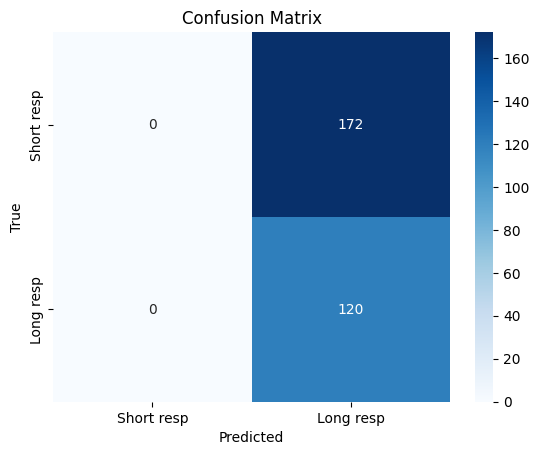

In [49]:
results = cross_validate(
    full_pipe, x, y,
    cv=skf,
    scoring=['roc_auc', 'f1'],
    return_train_score=True,
    n_jobs=-1,
    return_estimator=True
)

print(f"Train ROC-AUC : {results['train_roc_auc'].mean():.3f} ± {results['train_roc_auc'].std():.3f}")
print(f"Train  F1     : {results['train_f1'].mean():.3f} ± {results['train_f1'].std():.3f}")
print(f"Test ROC-AUC  : {results['test_roc_auc'].mean():.3f} ± {results['test_roc_auc'].std():.3f}")
print(f"Test F1       : {results['test_f1'].mean():.3f} ± {results['test_f1'].std():.3f}\n")

target_names = ['Short resp', 'Long resp']

y_pred = cross_val_predict(
    full_pipe, x, y, 
    cv=skf,
    n_jobs=-1
)

print(classification_report(
    y, y_pred,
    target_names=target_names
))

cm = confusion_matrix(y, y_pred)
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=target_names,
            yticklabels=target_names,
            cmap='Blues')
plt.ylabel('True'); plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

## Evaluation – LeaveOneGroupOut (by cohort)

In [50]:
# logo = LeaveOneGroupOut()
# groups = clinical_gex_filtered['source']

# print("Cohorts (groups):")
# print(groups.value_counts().to_string())
# print(f"\nNumber of LOGO folds: {logo.get_n_splits(groups=groups)}\n")

# if BINARY_PFS:
#     logo_results = cross_validate(
#         full_pipe, x, y,
#         cv=logo,
#         groups=groups,
#         scoring=['roc_auc', 'f1'],
#         return_train_score=True,
#         n_jobs=-1,
#     )

#     fold_df = pd.DataFrame({
#         'cohort':        [g for g in groups.unique()],
#         'test_roc_auc':  logo_results['test_roc_auc'],
#         'test_f1':       logo_results['test_f1'],
#         'train_roc_auc': logo_results['train_roc_auc'],
#         'train_f1':      logo_results['train_f1'],
#     })
#     print(fold_df.to_string(index=False))

#     print(f"\nTrain ROC-AUC : {logo_results['train_roc_auc'].mean():.3f} ± {logo_results['train_roc_auc'].std():.3f}")
#     print(f"Train  F1     : {logo_results['train_f1'].mean():.3f} ± {logo_results['train_f1'].std():.3f}")
#     print(f"Test ROC-AUC  : {logo_results['test_roc_auc'].mean():.3f} ± {logo_results['test_roc_auc'].std():.3f}")
#     print(f"Test  F1      : {logo_results['test_f1'].mean():.3f} ± {logo_results['test_f1'].std():.3f}")
#     target_names = ['Short resp', 'Long resp']

# else:
#     logo_results = cross_validate(
#         full_pipe, x, y,
#         cv=logo,
#         groups=groups,
#         scoring=['roc_auc_ovo', 'f1_macro'],
#         return_train_score=True,
#         n_jobs=-1,
#     )

#     fold_df = pd.DataFrame({
#         'cohort':             [g for g in groups.unique()],
#         'test_roc_auc_ovo':   logo_results['test_roc_auc_ovo'],
#         'test_f1_macro':      logo_results['test_f1_macro'],
#         'train_roc_auc_ovo':  logo_results['train_roc_auc_ovo'],
#         'train_f1_macro':     logo_results['train_f1_macro'],
#     })
#     print(fold_df.to_string(index=False))

#     print(f"\nTrain ROC-AUC (OVO): {logo_results['train_roc_auc_ovo'].mean():.3f} ± {logo_results['train_roc_auc_ovo'].std():.3f}")
#     print(f"Train Macro F1     : {logo_results['train_f1_macro'].mean():.3f} ± {logo_results['train_f1_macro'].std():.3f}")
#     print(f"Test ROC-AUC (OVO) : {logo_results['test_roc_auc_ovo'].mean():.3f} ± {logo_results['test_roc_auc_ovo'].std():.3f}")
#     print(f"Test Macro F1      : {logo_results['test_f1_macro'].mean():.3f} ± {logo_results['test_f1_macro'].std():.3f}")
#     target_names = ['Short resp', 'Intermediate', 'Long resp']

# y_pred_logo = cross_val_predict(
#     full_pipe, x, y,
#     cv=logo,
#     groups=groups,
#     n_jobs=-1,
# )

# print("\n" + classification_report(y, y_pred_logo, target_names=target_names))

# cm_logo = confusion_matrix(y, y_pred_logo)
# sns.heatmap(cm_logo, annot=True, fmt='d',
#             xticklabels=target_names,
#             yticklabels=target_names,
#             cmap='Blues')
# plt.ylabel('True'); plt.xlabel('Predicted')
# plt.title('Confusion Matrix – LeaveOneGroupOut (cohort)')
# plt.show()

## Overlap check


In [51]:
selected_per_fold = []
for tr, _ in skf.split(x, y):
    full_pipe.fit(x.iloc[tr], y.iloc[tr])
    names = full_pipe['preprocess'].get_feature_names_out()
    coefs = full_pipe['clf'].coef_[0]
    mask = coefs != 0
    selected_per_fold.append(set(names[mask]))

gex_per_fold = [{f for f in fold if f.startswith('gex__')} for fold in selected_per_fold]

common_gex = set.intersection(*gex_per_fold)
union_gex  = set.union(*gex_per_fold)
sizes_gex  = [len(s) for s in gex_per_fold]

print(f"GEX per-fold sizes : {sizes_gex}")
print(f"GEX in all folds   : {len(common_gex)} → {common_gex}")
print(f"GEX union size     : {len(union_gex)}")
print(f"GEX stability ratio: {len(common_gex) / max(1, min(sizes_gex)):.2f}")

GEX per-fold sizes : [0, 0, 0, 0, 0]
GEX in all folds   : 0 → set()
GEX union size     : 0
GEX stability ratio: 0.00


In [52]:
common = set.intersection(*selected_per_fold)
union  = set.union(*selected_per_fold)
sizes = [len(s) for s in selected_per_fold]

print(f"Feature selected per fold : {sizes}")
print(f"Feature in all folds   : {len(common)} → {common}")
print(f"Feature union size     : {len(union)}")
print(f"Feature stability ratio: {len(common) / max(1, min(sizes)):.2f}")

Feature selected per fold : [0, 0, 0, 0, 0]
Feature in all folds   : 0 → set()
Feature union size     : 0
Feature stability ratio: 0.00


## Explainability

In [53]:
print(results['test_roc_auc'])
print(results['test_f1'])

[0.5 0.5 0.5 0.5 0.5]
[0.57831325 0.57831325 0.58536585 0.58536585 0.58536585]


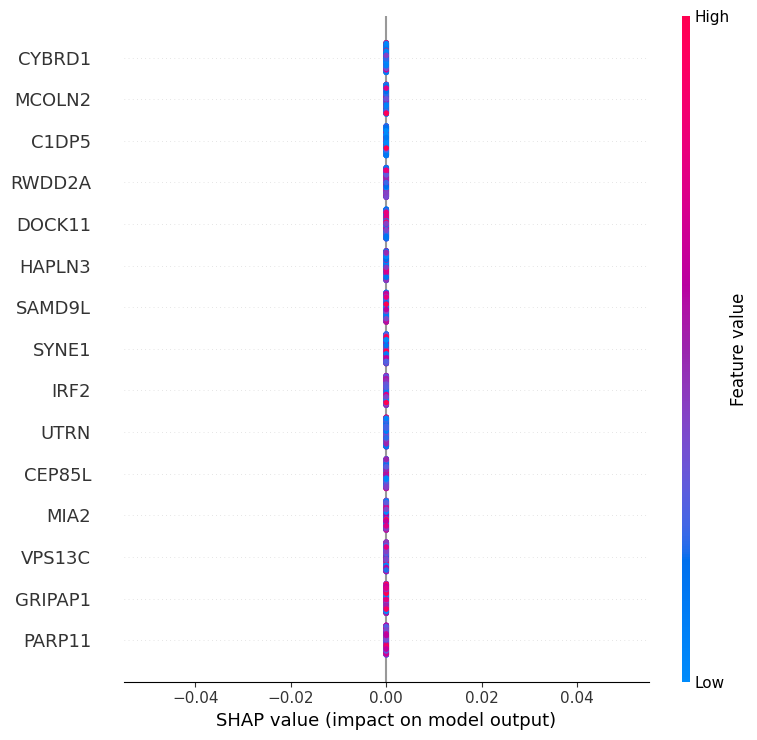

(292, 17)

In [54]:
best_model = results["estimator"][4][-1]

x_transformed = full_pipe[:-1].transform(x)  # x -> prep -> scaler

# Recover feature names after SelectKBest
preprocessed_feature_names = full_pipe['preprocess'].get_feature_names_out()
feature_names = np.array([name.split('__', 1)[-1] for name in preprocessed_feature_names])

explainer = shap.LinearExplainer(best_model, x_transformed)
shap_values = explainer(x_transformed)
shap_values.feature_names = feature_names.tolist()

shap.summary_plot(shap_values, x_transformed, feature_names=feature_names, max_display=15)
x_transformed.shape

In [55]:
for col in clinical_categorical_cols:
    print(f"{col} ({x[col].nunique(dropna=True)} values): {sorted(x[col].dropna().unique().tolist())}\n")

ETHNICITY (2 values): ['HISPANIC OR LATINO', 'NOT HISPANIC OR LATINO']

ICD_10 (35 values): ['C17.9', 'C18.9', 'C34.1', 'C34.3', 'C34.9', 'C43.51', 'C44.2', 'C44.4', 'C44.5', 'C44.6', 'C44.7', 'C44.9', 'C48.2', 'C49.0', 'C49.1', 'C49.2', 'C49.20', 'C49.3', 'C49.4', 'C49.5', 'C49.6', 'C49.9', 'C50.9', 'C51.9', 'C71.1', 'C74.9', 'C76.1', 'C76.2', 'C76.3', 'C77.0', 'C77.2', 'C77.3', 'C77.4', 'C77.5', 'C77.9']

MORPHOLOGY (8 values): ['8720/3', '8721/3', '8730/3', '8742/3', '8744/3', '8771/3', '8772/0', '8772/3']

SAMPLE_TYPE (3 values): ['Additional Metastatic', 'Metastatic', 'Primary Tumor']

PATH_M_STAGE (5 values): ['M0', 'M1', 'M1a', 'M1b', 'M1c']

PATH_N_STAGE (10 values): ['N0', 'N1', 'N1a', 'N1b', 'N2', 'N2a', 'N2b', 'N2c', 'N3', 'NX']

PATH_STAGE (14 values): ['I/II NOS', 'Stage 0', 'Stage I', 'Stage IA', 'Stage IB', 'Stage II', 'Stage IIA', 'Stage IIB', 'Stage IIC', 'Stage III', 'Stage IIIA', 'Stage IIIB', 'Stage IIIC', 'Stage IV']

PATH_T_STAGE (15 values): ['T0', 'T1', 'T1a', '

/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/sklearn/decomposition/_pca.py:646: RuntimeWarning: invalid value encountered in divide
  explained_variance_ratio_ = explained_variance_ / total_var


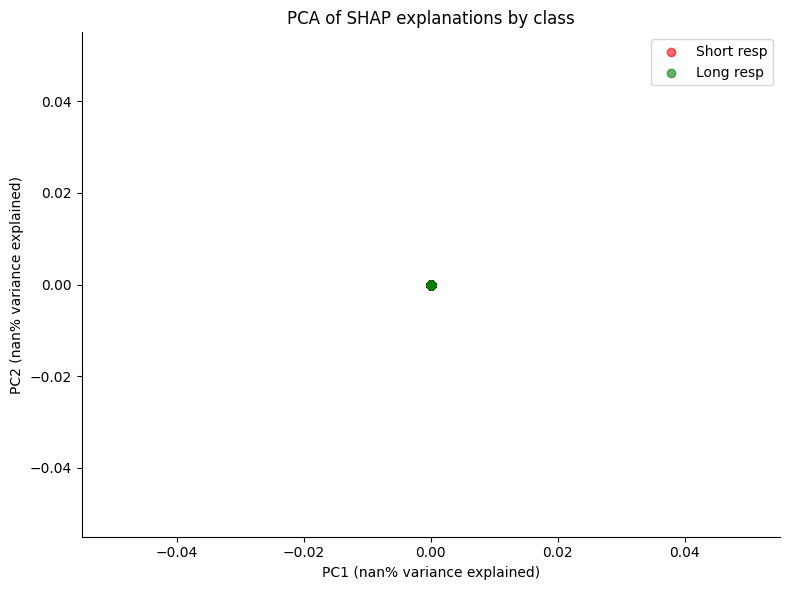

In [57]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap
import pacmap

def plot_shap_reduction(sv_2d, y_arr, method_name="PCA", var=None):
    colors = {0: "red", 1: "green"}
    labels = {0: "Short resp", 1: "Long resp"}
    fig, ax = plt.subplots(figsize=(8, 6))

    for cls in sorted(colors):
        mask = y_arr == cls
        ax.scatter(
            sv_2d[mask, 0], sv_2d[mask, 1],
            c=colors[cls], label=labels[cls],
            alpha=0.6,
        )

    if var is not None:
        ax.set_xlabel(f"PC1 ({var[0]:.1%} variance explained)")
        ax.set_ylabel(f"PC2 ({var[1]:.1%} variance explained)")
    else:
        ax.set_xlabel(f"{method_name} 1")
        ax.set_ylabel(f"{method_name} 2")

    ax.set_title(f"{method_name} of SHAP explanations by class")
    ax.legend()
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()

y_arr = np.array(y)

sv_input = shap_values.values                              # already (n_samples, n_features)

# PCA — pass explained variance
pca = PCA(n_components=2)
sv_2d = pca.fit_transform(sv_input)
plot_shap_reduction(sv_2d, y_arr, method_name="PCA", var=pca.explained_variance_ratio_)

# # t-SNE
# tsne = TSNE(n_components=2, perplexity=20, random_state=42)
# sv_2d = tsne.fit_transform(sv_input)
# plot_shap_reduction(sv_2d, y_arr, method_name="t-SNE")

# UMAP
# u_map = umap.UMAP(n_components=2, random_state=42)
# sv_2d = u_map.fit_transform(sv_input)
# plot_shap_reduction(sv_2d, y_arr, method_name="UMAP")

# # PaCMAP
# pac_map = pacmap.PaCMAP(n_components=2, random_state=42)
# sv_2d = pac_map.fit_transform(sv_input)
# plot_shap_reduction(sv_2d, y_arr, method_name="PaCMAP")
